# Metaheuristic Enhanced Model for Financial Markets

This notebook combines **Feature Selection** and **Feature Engineering** using Genetic Algorithms to enhance machine learning models for financial market trend prediction. 

## Workflow Overview:

0. **Settings**
1. **Installs and Imports**
2. **Data Cleaning**
3. **Baseline Feature Engineering** 
4. **Data Preprocessing** 
5. **Baseline Model Training and Testing** 
6. **Feature Selection using Genetic Algorithm (GA)**
7. **Feature Engineering using Genetic Algorithm (GA)**
8. **Enhanced Model Training and Testing**
9. **Comparison of Baseline and Enhanced Models**
10. **Save Results and Metadata**


## 0. Settings


In [1]:
DATASET = 'USA500IDXUSD_H1.csv'
VOLUME_TYPE_TICKER = True  # Set to true if the volume type is not the trading volume but the tick volume

## 1. Installs and Imports

First we install the requirements for the notebook and import the libraries

In [2]:
# Install dependencies from requirements.txt
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import required libraries
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import time
import pickle
import json

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical and mathematical tools
from scipy import stats

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Import our custom modules
from MH_Feature_Selection import GeneticAlgorithm
from MH_Feature_Engineering import engineer_adaptive_moving_average, engineer_fractal_dimension_indicator

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')

# For reproducibility
np.random.seed(42)

print("All libraries imported successfully!")
print("Custom metaheuristics modules loaded!")
print("Baseline feature engineering module will be imported when needed!")

c:\Users\nicol\anaconda3\envs\research_proj_2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\nicol\anaconda3\envs\research_proj_2\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


All libraries imported successfully!
Custom metaheuristics modules loaded!
Baseline feature engineering module will be imported when needed!


### 1.1 Store Notebook Data

All the outputs and settings of various models in the notebook are stored in a timestamped folder for statistical comparisons later.

In [4]:
# Create timestamped directory for this run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_directory = f"run_{timestamp}"
os.makedirs(run_directory, exist_ok=True)

print(f"Created run directory: {run_directory}")

# Create a README file to document this run
readme_content = f"""# Combined Metaheuristics Workflow Run
Run Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Timestamp: {timestamp}

## Workflow Components:
1. Data Loading and Cleaning
2. Baseline Feature Engineering  
3. Data Preprocessing (Time-series splits)
4. Baseline Model Training (RF, XGBoost)
5. GA Feature Selection
6. GA Feature Engineering (AMA, FDI)
7. Enhanced Model Training
8. Performance Comparison
9. Results Saving

## Files in this directory:
- *_baseline.pkl: Baseline models
- *_enhanced.pkl: Enhanced models with GA features
- selected_features_*.pkl: GA-selected feature subsets
- engineered_features_*.pkl: GA-engineered features
- X_*_scaled.pkl: Preprocessed data splits
- y_*.pkl: Target variable splits
- feature_names.pkl: Original feature names
- performance_comparison.csv: Results comparison
- README.txt: This file
"""

with open(os.path.join(run_directory, 'README.txt'), 'w') as f:
    f.write(readme_content)

print("Run documentation created!")

Created run directory: run_20251029_103554
Run documentation created!


### 1.2 Fetch Data
If a specific dataset is provided then that dataset will be used
If a specific ticker is provided, then we will first check if any data exists locally for that ticker. 
    If not, then data is downloaded.
    If yes, then that dataset is first updated to ensure the latest hours data in in the dataset.

In [5]:
print("Loading provided dataset...")
data = pd.read_csv(f'raw_data/{DATASET}')
print(f"Loaded data shape: {data.shape}")

print(f"Final data shape: {data.shape}")

Loading provided dataset...
Loaded data shape: (65663, 6)
Final data shape: (65663, 6)


## 2. Data cleaning
- Handle missing values with fill forward and fill backward
- Handle infinite values by replacing with NaN and filling
- Remove any remaining Nan rows

In [6]:
# Data cleaning and validation
print("Performing data cleaning...")

# Check for missing values
missing_values = data.isnull().sum()
print(f"\nMissing values per column:")
print(missing_values[missing_values > 0])

# Check for infinite values
numeric_cols = data.select_dtypes(include=[np.number]).columns
inf_values = np.isinf(data[numeric_cols]).sum()
print(f"\nInfinite values per column:")
print(inf_values[inf_values > 0])

# Handle missing values by forward fill and backward fill
'''
if missing_values.sum() > 0:
    print(f"Filling {missing_values.sum()} missing values...")
    data = data.fillna(method='ffill').fillna(method='bfill')

# Handle infinite values by replacing with NaN and then filling
if inf_values.sum() > 0:
    print(f"Replacing {inf_values.sum()} infinite values...")
    data[numeric_cols] = data[numeric_cols].replace([np.inf, -np.inf], np.nan)
    data = data.fillna(method='ffill').fillna(method='bfill')
'''

# Remove any remaining NaN rows
initial_rows = len(data)
data = data.dropna()
dropped_rows = initial_rows - len(data)
if dropped_rows > 0:
    print(f"Dropped {dropped_rows} rows with remaining NaN values")

print(f"\nCleaned data shape: {data.shape}")
print("Data cleaning completed!")

Performing data cleaning...

Missing values per column:
Series([], dtype: int64)

Infinite values per column:
Series([], dtype: int64)

Cleaned data shape: (65663, 6)
Data cleaning completed!


In [7]:
# Rename columns to match required OHLCV format
data.columns = ['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume']

# Parse datetime if present (adjust column name as needed)
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.set_index('Date')
elif 'Datetime' in data.columns:
    data['Datetime'] = pd.to_datetime(data['Datetime'])
    data = data.set_index('Datetime')
elif 'Timestamp' in data.columns:
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    data = data.set_index('Timestamp')

print(f"Data date range: {data.index[0]} to {data.index[-1]}")

# Display basic statistics for OHLCV data
print("\nOHLCV basic statistics:")
print(data[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

Data date range: 2013-05-23 01:00:00 to 2025-10-29 07:00:00

OHLCV basic statistics:
               Open          High           Low         Close        Volume
count  65663.000000  65663.000000  65663.000000  65663.000000  65663.000000
mean    3454.343402   3458.583865   3449.869544   3454.409825     54.867779
std     1334.451668   1335.796388   1333.005167   1334.479924     11.974040
min     1564.672000   1568.697000   1559.677000   1564.693000      1.000000
25%     2179.987500   2181.626500   2178.323000   2179.971000     57.000000
50%     3104.446000   3109.070000   3100.069000   3104.670000     60.000000
75%     4381.485500   4386.452500   4376.021500   4381.548500     60.000000
max     6910.442000   6913.199000   6907.133000   6912.499000    145.000000


## 2.2 Date Range
Set a daterange to be used
In this case; 6 months of data + 100 hours to account for lookback windows

In [8]:
# Define the date range or number of months for filtering
# Use the last N months of data plus 
months_to_use = 6
end_date_dynamic = data.index.max()
start_date_dynamic = end_date_dynamic - timedelta(days=months_to_use * 30)

# add a buffer of 100 hours to account for lookback periods in feature engineering
start_date_dynamic -= timedelta(hours=100)

# Filter the data based on the chosen option
#filtered_data = data.loc[start_date:end_date]  # Use this for specific date range
filtered_data = data.loc[start_date_dynamic:end_date_dynamic]  # Use this for last N months

print(f"Filtered data shape: {filtered_data.shape}")
print(f"Filtered data date range: {filtered_data.index.min()} to {filtered_data.index.max()}")

Filtered data shape: (2969, 5)
Filtered data date range: 2025-04-28 03:00:00 to 2025-10-29 07:00:00


## 3. Baseline Feature Engineering

Apply comprehensive feature engineering to create technical indicators and the target variable from raw OHLCV data.

In [9]:
# Import the baseline feature engineering function
from MH_feature_engineering_baseline import compute_baseline_features, compute_target_rule

print("Creating comprehensive technical indicators using the baseline feature engineering module...")

# Use the modularized feature engineering function
feature_df = compute_baseline_features(filtered_data, volume_type_ticker=VOLUME_TYPE_TICKER)

print(f"Baseline feature engineering completed!")
print(f"Generated {len([col for col in feature_df.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume']])} technical indicators")
print("Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical")

Creating comprehensive technical indicators using the baseline feature engineering module...
Baseline feature engineering completed!
Generated 111 technical indicators
Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical


## 3.1 - Target Feature Engineering

This section creates the target variable for the machine learning models. The target is a 3-class classification variable based on dynamic volatility thresholds:

- **Down (0)**: Price movement below the lower threshold.
- **Up (1)**: Price movement above the upper threshold.
- **Sideways (2)**: Price movement within the thresholds.

The thresholds are calculated using rolling volatility over a defined lookback period, and the future price movement is determined over a prediction horizon. This ensures the target variable reflects market trends while avoiding lookahead bias.

In [10]:
## Create Target Variable (3-Class Classification with Dynamic Thresholds)

# Set constants for target generation (matching Chosen_Features.ipynb)
LOOKBACK = 20  # Lookback period for volatility calculation
PREDICTION_HORIZON = 5  # Predict price movement 5 periods ahead
MULTIPLIER = 1  # Volatility multiplier for threshold calculation

print(f"Creating target variable with parameters:")
print(f"  - Lookback period: {LOOKBACK}")
print(f"  - Prediction horizon: {PREDICTION_HORIZON}")
print(f"  - Volatility multiplier: {MULTIPLIER}")

# Use the modularized target creation function
feature_df = compute_target_rule(
    feature_df, 
    lookback=LOOKBACK, 
    prediction_horizon=PREDICTION_HORIZON, 
    multiplier=MULTIPLIER
)

# Display target distribution
target_counts = feature_df['Target'].value_counts()
print("\nTarget Distribution:")
print(target_counts)
print(f"Down (0): {target_counts[0]/len(feature_df)*100:.2f}%")
print(f"Up (1): {target_counts[1]/len(feature_df)*100:.2f}%")
print(f"Sideways (2): {target_counts[2]/len(feature_df)*100:.2f}%")

# Use the engineered features as our main data
data = feature_df.copy()

# Remove any NaN values created by indicators
initial_rows = len(data)
data = data.dropna()
dropped_rows = initial_rows - len(data)

print(f"\nDropped {dropped_rows} rows due to NaN in technical indicators")
print(f"Final data shape: {data.shape}")

# Ensure the working_data directory exists
os.makedirs('working_data', exist_ok=True)

# Save engineered features to working_data folder
engineered_features_path = 'working_data/engineered_features.csv'
data.to_csv(engineered_features_path)
print(f"Saved engineered features to: {engineered_features_path}")

# Save feature names for later reference
feature_names = [col for col in data.columns if col != 'Target']
with open(os.path.join(run_directory, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)

print(f"\nTotal features available: {len(feature_names)}")
print(f"Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical")
print(f"Target variable: 'Target' (3-class: 0=Down, 1=Up, 2=Sideways)")

Creating target variable with parameters:
  - Lookback period: 20
  - Prediction horizon: 5
  - Volatility multiplier: 1

Target Distribution:
Target
2    1207
1    1044
0     713
Name: count, dtype: int64
Down (0): 24.06%
Up (1): 35.22%
Sideways (2): 40.72%

Dropped 191 rows due to NaN in technical indicators
Final data shape: (2773, 117)
Saved engineered features to: working_data/engineered_features.csv

Total features available: 116
Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical
Target variable: 'Target' (3-class: 0=Down, 1=Up, 2=Sideways)


## 4. Data Preprocessing

Perform time-series aware data splitting and feature scaling to prepare for model training.

In [11]:
# Prepare features and target
X = data[feature_names].copy()
y = data['Target'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Time-series aware data splitting (80% train, 10% validation, 10% test)
n_samples = len(data)
train_size = int(0.8 * n_samples)
val_size = int(0.1 * n_samples)

# Split data maintaining temporal order
X_train = X.iloc[:train_size].copy()
X_val = X.iloc[train_size:train_size + val_size].copy()
X_test = X.iloc[train_size + val_size:].copy()

y_train = y.iloc[:train_size].copy()
y_val = y.iloc[train_size:train_size + val_size].copy()
y_test = y.iloc[train_size + val_size:].copy()

print(f"\nTime-series splits:")
print(f"Training: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in each split
print(f"\nClass distribution:")
print(f"Train: {y_train.value_counts().to_dict()}")
print(f"Validation: {y_val.value_counts().to_dict()}")
print(f"Test: {y_test.value_counts().to_dict()}")

Features shape: (2773, 116)
Target shape: (2773,)

Time-series splits:
Training: (2218, 116) (80.0%)
Validation: (277, 116) (10.0%)
Test: (278, 116) (10.0%)

Class distribution:
Train: {2: 905, 1: 783, 0: 530}
Validation: {2: 112, 1: 94, 0: 71}
Test: {1: 113, 2: 103, 0: 62}


In [12]:
# Feature scaling
print("Applying feature scaling...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print("Feature scaling completed!")

# Save preprocessed data
with open(os.path.join(run_directory, 'X_train_scaled.pkl'), 'wb') as f:
    pickle.dump(X_train_scaled, f)
with open(os.path.join(run_directory, 'X_val_scaled.pkl'), 'wb') as f:
    pickle.dump(X_val_scaled, f)
with open(os.path.join(run_directory, 'X_test_scaled.pkl'), 'wb') as f:
    pickle.dump(X_test_scaled, f)
with open(os.path.join(run_directory, 'y_train.pkl'), 'wb') as f:
    pickle.dump(y_train, f)
with open(os.path.join(run_directory, 'y_val.pkl'), 'wb') as f:
    pickle.dump(y_val, f)
with open(os.path.join(run_directory, 'y_test.pkl'), 'wb') as f:
    pickle.dump(y_test, f)
with open(os.path.join(run_directory, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print("Preprocessed data saved!")

Applying feature scaling...
Feature scaling completed!
Preprocessed data saved!


## 4. Baseline Model Training and Testing

Train baseline models (Random Forest, XGBoost, ANN) on all features and evaluate their performance.

In [13]:
# Define function to evaluate model performance
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model performance and return metrics"""
    y_pred = model.predict(X_test)
    
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted')
    }
    
    return metrics, y_pred

# Store baseline results
baseline_results = []
baseline_models = {}

Training Random Forest baseline model...
Random Forest Baseline Results:
  accuracy: 0.3921
  precision: 0.3601
  recall: 0.3921
  f1_score: 0.3028


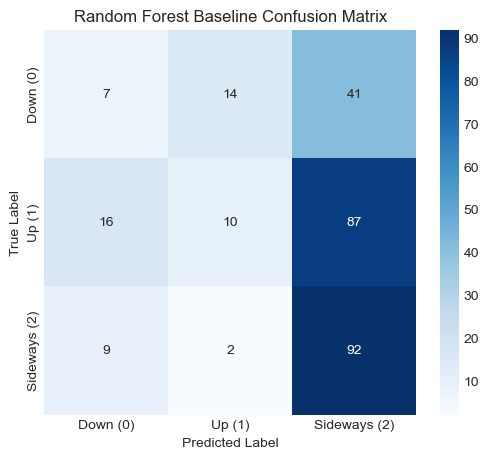

<Figure size 640x480 with 0 Axes>

In [14]:
# Train Random Forest baseline model
print("Training Random Forest baseline model...")

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_scaled, y_train)

# Evaluate on test set
rf_metrics, rf_pred = evaluate_model(rf_baseline, X_test_scaled, y_test, 'Random Forest Baseline')
baseline_results.append(rf_metrics)
baseline_models['rf'] = rf_baseline

print(f"Random Forest Baseline Results:")
for key, value in rf_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'], 
            yticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Baseline Confusion Matrix')
plt.show()
# save confusion matrix figure
plt.savefig(os.path.join(run_directory, 'rf_baseline_confusion_matrix.png'))

# Save model
with open(os.path.join(run_directory, 'rf_baseline.pkl'), 'wb') as f:
    pickle.dump(rf_baseline, f)



Training XGBoost baseline model...
XGBoost Baseline Results:
  accuracy: 0.4209
  precision: 0.4227
  recall: 0.4209
  f1_score: 0.3533


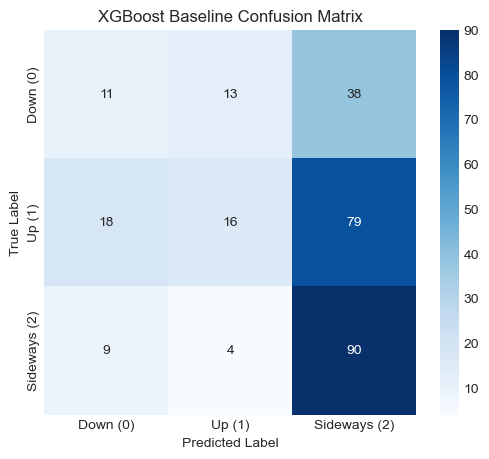

<Figure size 640x480 with 0 Axes>

In [15]:
# Train XGBoost baseline model
print("Training XGBoost baseline model...")

xgb_baseline = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_baseline.fit(X_train_scaled, y_train)

# Evaluate on test set
xgb_metrics, xgb_pred = evaluate_model(xgb_baseline, X_test_scaled, y_test, 'XGBoost Baseline')
baseline_results.append(xgb_metrics)
baseline_models['xgb'] = xgb_baseline

print(f"XGBoost Baseline Results:")
for key, value in xgb_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# confusion matrix
rf_cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'], 
            yticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Baseline Confusion Matrix')
plt.show()
# save the confusion matrix
plt.savefig(os.path.join(run_directory, 'xgb_baseline_confusion_matrix.png'))

# Save model
with open(os.path.join(run_directory, 'xgb_baseline.pkl'), 'wb') as f:
    pickle.dump(xgb_baseline, f)

In [16]:
# Display baseline results summary
print("\n" + "="*60)
print("BASELINE MODEL RESULTS SUMMARY")
print("="*60)

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df.round(4))

# Save baseline results
baseline_df.to_csv(os.path.join(run_directory, 'baseline_results.csv'), index=False)
print("\nBaseline results saved!")


BASELINE MODEL RESULTS SUMMARY
                    model  accuracy  precision  recall  f1_score
0  Random Forest Baseline    0.3921     0.3601  0.3921    0.3028
1        XGBoost Baseline    0.4209     0.4227  0.4209    0.3533

Baseline results saved!


## 5. Feature Selection using Genetic Algorithm (GA)

Apply GA-based feature selection to identify the most relevant features for each model type.

GA FEATURE SELECTION FOR RANDOM FOREST
Enhanced GA Configuration:
  • Population size: 50
  • Strategy: Dynamic rates only (ILM/DHC for small population)
  • Feature range: 15-50
  • Elite preservation: 5 individuals
  • Natural disaster trigger: 5 stagnant generations
  • Diversity threshold: 0
Using ILM/DHC strategy for small population (50 individuals)
Initializing population: 15-50 features
Created population with feature counts: 15-49 (avg: 31.5)
Guided individuals: 12/50
Starting Streamlined GA:
  Population: 50, Generations: 30
  Features range: 15-50
  Model: random_forest, CV folds: 5
  Dynamic rates: ILM/DHC (0%→100% mutation, 100%→0% crossover for small populations)
  Initial feature counts: 15-49 (avg: 31.5)
Gen 0: Dynamic rates - Crossover: 0.990, Mutation: 0.010 (ILM_DHC)
Gen  0: Fitness=0.7045, Best=15, Pop=[15-27.1-46], Div=0.385, Stag=0, C/M=0.99/0.01
Gen  1: Fitness=0.7154, Best=28, Pop=[15-27.1-40], Div=0.278, Stag=0
Gen  2: Fitness=0.7164, Best=30, Pop=[15-27.1-36],

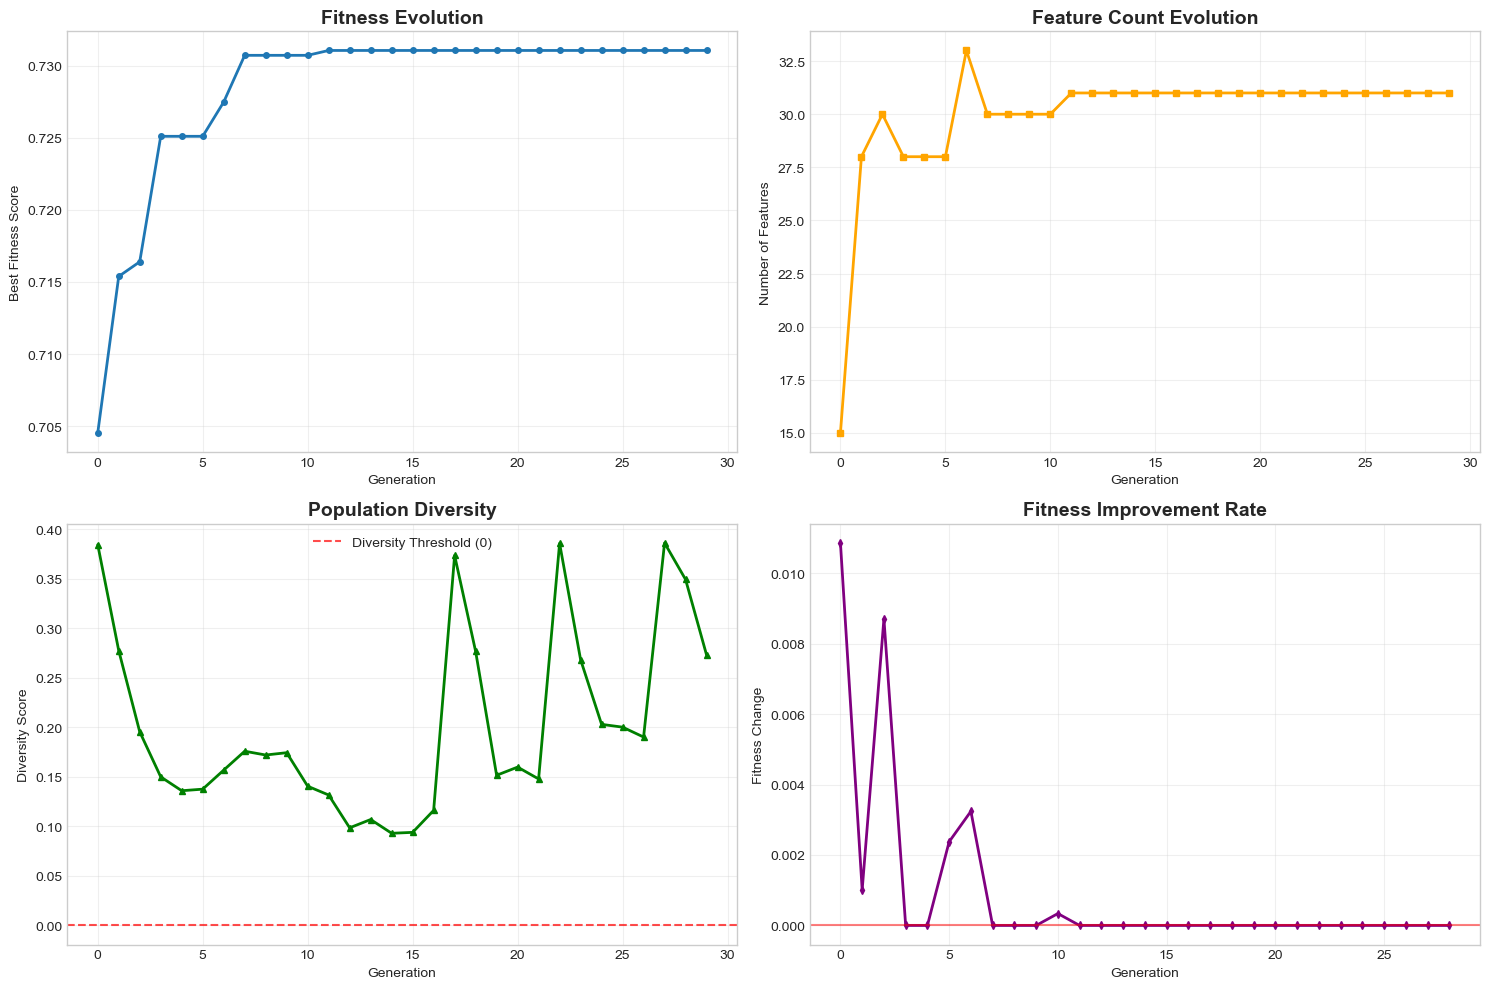


Evolution Summary:
Final fitness: 0.7311
Best fitness: 0.7311
Average fitness: 0.7284
Fitness std: 0.0060
Final diversity: 0.273
Average diversity: 0.204
Total generations: 30
Early stopping at: 3 generations without improvement


In [17]:
# GA Feature Selection for Random Forest
print("="*60)
print("GA FEATURE SELECTION FOR RANDOM FOREST")
print("="*60)

# Configure enhanced GA parameters for improved performance
ga_params = {
    'pop_size': 50,                 # Population size
    'crossover_rate': 0.8,          # Base crossover rate (modified by dynamic rates)
    'mutation_rate': 0.2,           # Base mutation rate (modified by dynamic rates)
    'max_generations': 30,          # Maximum generations
    'min_features': 15,             # Minimum features to select
    'max_features': 50,             # Maximum features to select
    'cv_folds': 5,                  # Cross-validation folds
    'adaptive_rates': False,        # DISABLED - Use only dynamic rates for simplicity
    'diversity_threshold': 0,       # Lowered for more aggressive diversity management
    'calm_before_storm': 5,         # Reduced for faster adaptation (natural disaster trigger)
    'elite_size': 5,                # Increased elite preservation for better convergence
    'debug': True,                  # Enable detailed logging
    'use_dynamic_rates': True       # Enable dynamic rate strategy (ILM/DHC for pop_size=50)
}

print("Enhanced GA Configuration:")
print(f"  • Population size: {ga_params['pop_size']}")
print(f"  • Strategy: Dynamic rates only (ILM/DHC for small population)")
print(f"  • Feature range: {ga_params['min_features']}-{ga_params['max_features']}")
print(f"  • Elite preservation: {ga_params['elite_size']} individuals")
print(f"  • Natural disaster trigger: {ga_params['calm_before_storm']} stagnant generations")
print(f"  • Diversity threshold: {ga_params['diversity_threshold']}")

# Run GA feature selection for Random Forest
start_time = time.time()

ga_rf = GeneticAlgorithm(
    X_train_scaled, y_train, feature_names,
    model_type='random_forest',
    **ga_params
)

selected_features_rf = ga_rf.run(verbose=True)

rf_ga_time = time.time() - start_time
print(f"\nGA Feature Selection for Random Forest completed in {rf_ga_time:.2f} seconds")
print(f"Selected {len(selected_features_rf[2])} features for Random Forest:")
print(selected_features_rf[2][:10], "..." if len(selected_features_rf[2]) > 10 else "")

# Save selected features
with open(os.path.join(run_directory, 'selected_features_rf.pkl'), 'wb') as f:
    pickle.dump(selected_features_rf, f)

# Plot convergence for Random Forest GA
ga_rf.plot_convergence()

GA FEATURE SELECTION FOR XGBOOST
Using ILM/DHC strategy for small population (50 individuals)
Initializing population: 15-50 features
Created population with feature counts: 15-49 (avg: 31.5)
Guided individuals: 12/50
Starting Streamlined GA:
  Population: 50, Generations: 30
  Features range: 15-50
  Model: xgboost, CV folds: 5
  Dynamic rates: ILM/DHC (0%→100% mutation, 100%→0% crossover for small populations)
  Initial feature counts: 15-49 (avg: 31.5)
Gen 0: Dynamic rates - Crossover: 0.990, Mutation: 0.010 (ILM_DHC)
Gen  0: Fitness=0.6895, Best=15, Pop=[15-31.1-45], Div=0.385, Stag=0, C/M=0.99/0.01
Gen  1: Fitness=0.6895, Best=15, Pop=[15-30.7-45], Div=0.368, Stag=1
Gen  2: Fitness=0.6895, Best=15, Pop=[15-27.4-45], Div=0.339, Stag=2
Gen  3: Fitness=0.7182, Best=18, Pop=[15-22.8-35], Div=0.301, Stag=0
Gen  4: Fitness=0.7182, Best=18, Pop=[15-20.7-41], Div=0.204, Stag=1
Gen 5: Dynamic rates - Crossover: 0.833, Mutation: 0.167 (ILM_DHC)
Gen  5: Fitness=0.7182, Best=18, Pop=[15-19.2-

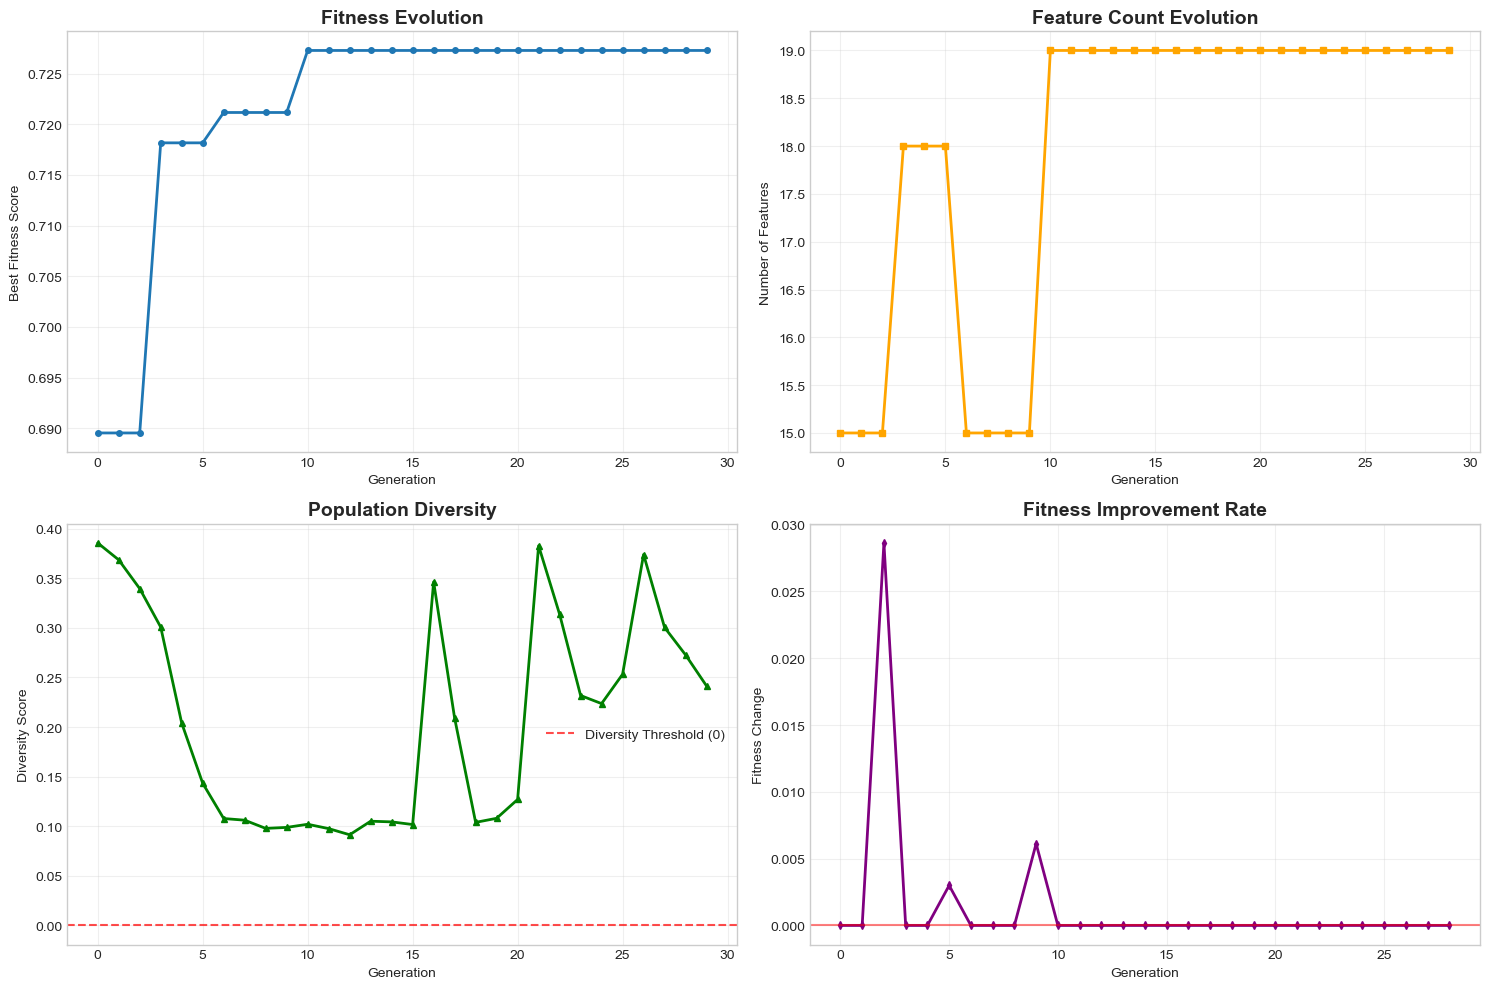


Evolution Summary:
Final fitness: 0.7273
Best fitness: 0.7273
Average fitness: 0.7218
Fitness std: 0.0112
Final diversity: 0.241
Average diversity: 0.208
Total generations: 30
Early stopping at: 4 generations without improvement


In [18]:
# GA Feature Selection for XGBoost
print("="*60)
print("GA FEATURE SELECTION FOR XGBOOST")
print("="*60)

# Run GA feature selection for XGBoost
start_time = time.time()

ga_xgb = GeneticAlgorithm(
    X_train_scaled, y_train, feature_names,
    model_type='xgboost',
    **ga_params
)

selected_features_xgb = ga_xgb.run(verbose=True)

xgb_ga_time = time.time() - start_time
print(f"\nGA Feature Selection for XGBoost completed in {xgb_ga_time:.2f} seconds")
print(f"Selected {len(selected_features_xgb)} features for XGBoost:")
print(selected_features_xgb[:10], "..." if len(selected_features_xgb) > 10 else "")

# Save selected features
with open(os.path.join(run_directory, 'selected_features_xgb.pkl'), 'wb') as f:
    pickle.dump(selected_features_xgb, f)

ga_xgb.plot_convergence()

In [19]:
# Analyze feature selection results
print("\n" + "="*60)
print("FEATURE SELECTION ANALYSIS")
print("="*60)

selection_summary = {
    'Random Forest': len(selected_features_rf),
    'XGBoost': len(selected_features_xgb)
}

print("Selected feature counts:")
for model, count in selection_summary.items():
    reduction = (1 - count/len(feature_names)) * 100
    print(f"  {model}: {count} features ({reduction:.1f}% reduction)")

# Find common features across models
common_features = set(selected_features_rf[2]) & set(selected_features_xgb[2])
print(f"\nCommon features across all models: {len(common_features)}")
if len(common_features) > 0:
    print("Common features:", list(common_features)[:10], "..." if len(common_features) > 10 else "")


FEATURE SELECTION ANALYSIS
Selected feature counts:
  Random Forest: 3 features (97.4% reduction)
  XGBoost: 3 features (97.4% reduction)

Common features across all models: 11
Common features: ['MACD_Signal', 'OBV_TickDev', 'MACD_Line', 'Volume_Osc_tick_12_26', 'ATR_Ratio_20', 'GK_Volatility', 'Volume_Osc_tick_5_10', 'Normalized_Vol_10', 'Chaikin_Vol_10', 'Returns_Skewness_20'] ...


## 6. Feature Engineering using Genetic Algorithm (GA)

Use GA to engineer new optimized features (Adaptive Moving Average, Fractal Dimension Indicator) and add them to the selected feature subsets.

In [20]:
# Prepare data for feature engineering (use original unscaled data)
print("="*60)
print("GA FEATURE ENGINEERING")
print("="*60)

# Use the original data for feature engineering
engineering_data = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
engineering_target = data['Target'].copy()

print(f"Data for feature engineering: {engineering_data.shape}")
print(f"Target distribution: {engineering_target.value_counts().to_dict()}")

GA FEATURE ENGINEERING
Data for feature engineering: (2773, 5)
Target distribution: {2: 1120, 1: 990, 0: 663}


In [21]:
# Engineer Adaptive Moving Average (AMA) using GA
print("Engineering Adaptive Moving Average (AMA)...")

start_time = time.time()

# Configure GA parameters for feature engineering
ga_fe_params = {
    'pop_size': 30,
    'max_generations': 20,
    'crossover_rate': 0.8,
    'mutation_rate': 0.2,
    'cv_folds': 3,
    'random_state': 42
}

# Engineer AMA feature
ama_feature, ama_details = engineer_adaptive_moving_average(
    engineering_data, engineering_target, **ga_fe_params
)

ama_time = time.time() - start_time
print(f"AMA engineering completed in {ama_time:.2f} seconds")
print(f"Best AMA parameters: {ama_details['best_parameters']}")
print(f"AMA fitness: {ama_details['best_fitness']:.4f}")

# Add AMA to the dataset
ama_feature_name = 'AMA_GA_Optimized'

Engineering Adaptive Moving Average (AMA)...
Starting GA Feature Engineering for AMA
Population: 30, Generations: 20
------------------------------------------------------------
Generation   0: Best=0.5032, Avg=0.4979
Generation   5: Best=0.5032, Avg=0.5012
Generation  10: Best=0.5032, Avg=0.5013
Generation  15: Best=0.5032, Avg=0.5005
------------------------------------------------------------
GA completed! Best fitness: 0.5032
Best parameters: [0.2438400315854124, 42, 8, 47]
AMA engineering completed in 397.93 seconds
Best AMA parameters: [0.2438400315854124, 42, 8, 47]
AMA fitness: 0.5032


In [22]:
# Engineer Fractal Dimension Indicator (FDI) using GA
print("Engineering Fractal Dimension Indicator (FDI)...")

start_time = time.time()

# Engineer FDI feature
fdi_feature, fdi_details = engineer_fractal_dimension_indicator(
    engineering_data, engineering_target, **ga_fe_params
)

fdi_time = time.time() - start_time
print(f"FDI engineering completed in {fdi_time:.2f} seconds")
print(f"Best FDI parameters: {fdi_details['best_parameters']}")
print(f"FDI fitness: {fdi_details['best_fitness']:.4f}")

# Add FDI to the dataset
fdi_feature_name = 'FDI_GA_Optimized'

Engineering Fractal Dimension Indicator (FDI)...
Starting GA Feature Engineering for FDI
Population: 30, Generations: 20
------------------------------------------------------------
Generation   0: Best=0.5396, Avg=0.5037
Generation   5: Best=0.5512, Avg=0.5402
Generation  10: Best=0.5914, Avg=0.5604
Generation  15: Best=0.5946, Avg=0.5732
------------------------------------------------------------
GA completed! Best fitness: 0.5955
Best parameters: [14, 1.8552187197860246, 2.0]
FDI engineering completed in 441.81 seconds
Best FDI parameters: [14, 1.8552187197860246, 2.0]
FDI fitness: 0.5955


In [23]:
# Combine engineered features with selected features
print("Combining engineered features with selected feature subsets...")

# Ensure engineered features have the same length as original data
if len(ama_feature) != len(data):
    print(f"Adjusting AMA feature length from {len(ama_feature)} to {len(data)}")
    ama_feature = ama_feature[:len(data)]

if len(fdi_feature) != len(data):
    print(f"Adjusting FDI feature length from {len(fdi_feature)} to {len(data)}")
    fdi_feature = fdi_feature[:len(data)]

# Add engineered features to the dataset splits
# First, add to the original data
data_with_engineered = data.copy()
data_with_engineered[ama_feature_name] = ama_feature
data_with_engineered[fdi_feature_name] = fdi_feature

# Remove any NaN values that might have been introduced
data_with_engineered = data_with_engineered.dropna()

print(f"Data with engineered features shape: {data_with_engineered.shape}")

# Save engineered features details
engineered_features_info = {
    'ama_feature_name': ama_feature_name,
    'ama_details': ama_details,
    'fdi_feature_name': fdi_feature_name,
    'fdi_details': fdi_details
}

with open(os.path.join(run_directory, 'engineered_features_info.pkl'), 'wb') as f:
    pickle.dump(engineered_features_info, f)

Combining engineered features with selected feature subsets...
Data with engineered features shape: (2773, 119)


In [24]:
# Create enhanced feature subsets for each model
print("Creating enhanced feature subsets...")

# Combine selected features with engineered features for each model
enhanced_features_rf = list(selected_features_rf[2]) + [ama_feature_name, fdi_feature_name]
enhanced_features_xgb = list(selected_features_xgb[2]) + [ama_feature_name, fdi_feature_name]

print(f"Enhanced RF features: {len(enhanced_features_rf)} ({len(selected_features_rf)} + 2 engineered)")
print(f"Enhanced XGBoost features: {len(enhanced_features_xgb)} ({len(selected_features_xgb)} + 2 engineered)")

# Save enhanced feature lists
enhanced_features = {
    'rf': enhanced_features_rf,
    'xgb': enhanced_features_xgb
}

with open(os.path.join(run_directory, 'enhanced_features.pkl'), 'wb') as f:
    pickle.dump(enhanced_features, f)

print("Enhanced feature subsets saved!")

Creating enhanced feature subsets...
Enhanced RF features: 33 (3 + 2 engineered)
Enhanced XGBoost features: 21 (3 + 2 engineered)
Enhanced feature subsets saved!


## 7. Enhanced Model Hyperparameter Tuning, Training and Testing

Train models using the combined selected and engineered features, then evaluate their performance.

In [25]:
# Create enhanced datasets with selected + engineered features
print("="*60)
print("CREATING ENHANCED DATASETS WITH ENGINEERED FEATURES")
print("="*60)

# Prepare enhanced datasets for each model
enhanced_datasets = {}

# Get the indices that match our original splits
train_indices = X_train.index
val_indices = X_val.index  
test_indices = X_test.index

print(f"Original data splits:")
print(f"  Train: {len(train_indices)} samples")
print(f"  Validation: {len(val_indices)} samples") 
print(f"  Test: {len(test_indices)} samples")

# Align engineered features with the split indices
# Get the overlapping indices between data_with_engineered and our splits
available_indices = data_with_engineered.index
train_available = train_indices.intersection(available_indices)
val_available = val_indices.intersection(available_indices)
test_available = test_indices.intersection(available_indices)

print(f"\nAfter aligning with engineered features:")
print(f"  Train: {len(train_available)} samples")
print(f"  Validation: {len(val_available)} samples")
print(f"  Test: {len(test_available)} samples")

# Create enhanced datasets for each model
for model_name, feature_list in enhanced_features.items():
    print(f"\nCreating enhanced dataset for {model_name.upper()}...")
    
    # Extract features for this model from data_with_engineered
    X_enhanced = data_with_engineered[feature_list].copy()
    y_enhanced = data_with_engineered['Target'].copy()
    
    # Create time-series splits using available indices
    X_train_enh = X_enhanced.loc[train_available].copy()
    X_val_enh = X_enhanced.loc[val_available].copy() 
    X_test_enh = X_enhanced.loc[test_available].copy()
    
    y_train_enh = y_enhanced.loc[train_available].copy()
    y_val_enh = y_enhanced.loc[val_available].copy()
    y_test_enh = y_enhanced.loc[test_available].copy()
    
    # Apply feature scaling
    scaler_enh = StandardScaler()
    X_train_enh_scaled = scaler_enh.fit_transform(X_train_enh)
    X_val_enh_scaled = scaler_enh.transform(X_val_enh)
    X_test_enh_scaled = scaler_enh.transform(X_test_enh)
    
    # Convert back to DataFrames
    X_train_enh_scaled = pd.DataFrame(X_train_enh_scaled, columns=feature_list, index=train_available)
    X_val_enh_scaled = pd.DataFrame(X_val_enh_scaled, columns=feature_list, index=val_available)
    X_test_enh_scaled = pd.DataFrame(X_test_enh_scaled, columns=feature_list, index=test_available)
    
    # Store in enhanced datasets
    enhanced_datasets[model_name] = {
        'X_train': X_train_enh_scaled,
        'X_val': X_val_enh_scaled,
        'X_test': X_test_enh_scaled,
        'y_train': y_train_enh,
        'y_val': y_val_enh,
        'y_test': y_test_enh,
        'scaler': scaler_enh,
        'features': feature_list
    }
    
    # Save enhanced scaler
    with open(os.path.join(run_directory, f'scaler_{model_name}_enhanced.pkl'), 'wb') as f:
        pickle.dump(scaler_enh, f)
    
    print(f"  Enhanced {model_name.upper()} dataset created:")
    print(f"    Features: {len(feature_list)} ({len(feature_list)-2} selected + 2 engineered)")
    print(f"    Train: {X_train_enh_scaled.shape}")
    print(f"    Validation: {X_val_enh_scaled.shape}")
    print(f"    Test: {X_test_enh_scaled.shape}")

print(f"\nEnhanced datasets created successfully!")

# Hyperparameter Tuning for Enhanced Models
print("\n" + "="*60)
print("HYPERPARAMETER TUNING FOR ENHANCED MODELS")
print("="*60)

from sklearn.model_selection import GridSearchCV
import json

# Define hyperparameter grids
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Store best parameters
best_params = {}

# Hyperparameter tuning for Random Forest
print("Hyperparameter tuning for Random Forest...")
rf_data = enhanced_datasets['rf']

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,  # 3-fold CV for time efficiency
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Combine train and validation for hyperparameter tuning
X_rf_tune = pd.concat([rf_data['X_train'], rf_data['X_val']])
y_rf_tune = pd.concat([rf_data['y_train'], rf_data['y_val']])

rf_grid_search.fit(X_rf_tune, y_rf_tune)

best_params['rf'] = rf_grid_search.best_params_
print(f"Best RF parameters: {rf_grid_search.best_params_}")
print(f"Best RF CV score: {rf_grid_search.best_score_:.4f}")

# Save RF best parameters
with open(os.path.join(run_directory, 'rf_enhanced_best_params.json'), 'w') as f:
    json.dump(rf_grid_search.best_params_, f, indent=2)

# Hyperparameter tuning for XGBoost
print("\nHyperparameter tuning for XGBoost...")
xgb_data = enhanced_datasets['xgb']

xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid,
    cv=3,  # 3-fold CV for time efficiency
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Combine train and validation for hyperparameter tuning
X_xgb_tune = pd.concat([xgb_data['X_train'], xgb_data['X_val']])
y_xgb_tune = pd.concat([xgb_data['y_train'], xgb_data['y_val']])

xgb_grid_search.fit(X_xgb_tune, y_xgb_tune)

best_params['xgb'] = xgb_grid_search.best_params_
print(f"Best XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid_search.best_score_:.4f}")

# Save XGBoost best parameters
with open(os.path.join(run_directory, 'xgb_enhanced_best_params.json'), 'w') as f:
    json.dump(xgb_grid_search.best_params_, f, indent=2)

print("\nHyperparameter tuning completed!")

# Train Enhanced Models with Tuned Hyperparameters
print("\n" + "="*60)
print("TRAINING ENHANCED MODELS WITH TUNED HYPERPARAMETERS")
print("="*60)

# Train Enhanced Random Forest Model with best parameters
print("Training Enhanced Random Forest with tuned parameters...")
rf_enhanced = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **best_params['rf']
)

rf_enhanced.fit(X_rf_tune, y_rf_tune)

# Evaluate enhanced Random Forest on test set
rf_enh_metrics, rf_enh_pred = evaluate_model(rf_enhanced, rf_data['X_test'], rf_data['y_test'], 'Random Forest Enhanced')

print(f"Enhanced Random Forest Results:")
for key, value in rf_enh_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Save enhanced Random Forest model
with open(os.path.join(run_directory, 'rf_enhanced_tuned.pkl'), 'wb') as f:
    pickle.dump(rf_enhanced, f)

# Train Enhanced XGBoost Model with best parameters
print("\nTraining Enhanced XGBoost with tuned parameters...")
xgb_enhanced = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    **best_params['xgb']
)

xgb_enhanced.fit(X_xgb_tune, y_xgb_tune)

# Evaluate enhanced XGBoost on test set
xgb_enh_metrics, xgb_enh_pred = evaluate_model(xgb_enhanced, xgb_data['X_test'], xgb_data['y_test'], 'XGBoost Enhanced')

print(f"Enhanced XGBoost Results:")
for key, value in xgb_enh_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Save enhanced XGBoost model
with open(os.path.join(run_directory, 'xgb_enhanced_tuned.pkl'), 'wb') as f:
    pickle.dump(xgb_enhanced, f)

print("\n" + "="*60)
print("ENHANCED MODEL TRAINING WITH HYPERPARAMETER TUNING COMPLETED")
print("="*60)

CREATING ENHANCED DATASETS WITH ENGINEERED FEATURES
Original data splits:
  Train: 2218 samples
  Validation: 277 samples
  Test: 278 samples

After aligning with engineered features:
  Train: 2218 samples
  Validation: 277 samples
  Test: 278 samples

Creating enhanced dataset for RF...
  Enhanced RF dataset created:
    Features: 33 (31 selected + 2 engineered)
    Train: (2218, 33)
    Validation: (277, 33)
    Test: (278, 33)

Creating enhanced dataset for XGB...
  Enhanced XGB dataset created:
    Features: 21 (19 selected + 2 engineered)
    Train: (2218, 21)
    Validation: (277, 21)
    Test: (278, 21)

Enhanced datasets created successfully!

HYPERPARAMETER TUNING FOR ENHANCED MODELS
Hyperparameter tuning for Random Forest...
Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best RF parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV score: 0.4653

Hyperparameter tuning for XGBoost...


## 8. Comparison of Baseline and Enhanced Models

Compare the performance of baseline models vs enhanced models with GA-selected and engineered features.

In [26]:
# Compile all results for comparison
print("="*60)
print("PERFORMANCE COMPARISON: BASELINE VS ENHANCED")
print("="*60)

# Collect enhanced results
enhanced_results = [rf_enh_metrics, xgb_enh_metrics]

# Create comprehensive comparison
all_results = baseline_results + enhanced_results
comparison_df = pd.DataFrame(all_results)

print("Complete Results Comparison:")
print(comparison_df.round(4))

# Calculate improvements
improvements = []
model_pairs = [
    ('Random Forest Baseline', 'Random Forest Enhanced'),
    ('XGBoost Baseline', 'XGBoost Enhanced')
]

for baseline_name, enhanced_name in model_pairs:
    baseline_row = comparison_df[comparison_df['model'] == baseline_name].iloc[0]
    enhanced_row = comparison_df[comparison_df['model'] == enhanced_name].iloc[0]
    
    improvement = {
        'model_pair': f"{baseline_name} → {enhanced_name}",
        'accuracy_improvement': enhanced_row['accuracy'] - baseline_row['accuracy'],
        'precision_improvement': enhanced_row['precision'] - baseline_row['precision'],
        'recall_improvement': enhanced_row['recall'] - baseline_row['recall'],
        'f1_improvement': enhanced_row['f1_score'] - baseline_row['f1_score']
    }
    improvements.append(improvement)

improvements_df = pd.DataFrame(improvements)
print("\n" + "="*60)
print("IMPROVEMENTS (Enhanced - Baseline)")
print("="*60)
print(improvements_df.round(4))

PERFORMANCE COMPARISON: BASELINE VS ENHANCED
Complete Results Comparison:
                    model  accuracy  precision  recall  f1_score
0  Random Forest Baseline    0.3921     0.3601  0.3921    0.3028
1        XGBoost Baseline    0.4209     0.4227  0.4209    0.3533
2  Random Forest Enhanced    0.4388     0.3968  0.4388    0.3732
3        XGBoost Enhanced    0.4424     0.3888  0.4424    0.3798

IMPROVEMENTS (Enhanced - Baseline)
                                        model_pair  accuracy_improvement  \
0  Random Forest Baseline → Random Forest Enhanced                0.0468   
1              XGBoost Baseline → XGBoost Enhanced                0.0216   

   precision_improvement  recall_improvement  f1_improvement  
0                 0.0367              0.0468          0.0704  
1                -0.0339              0.0216          0.0265  


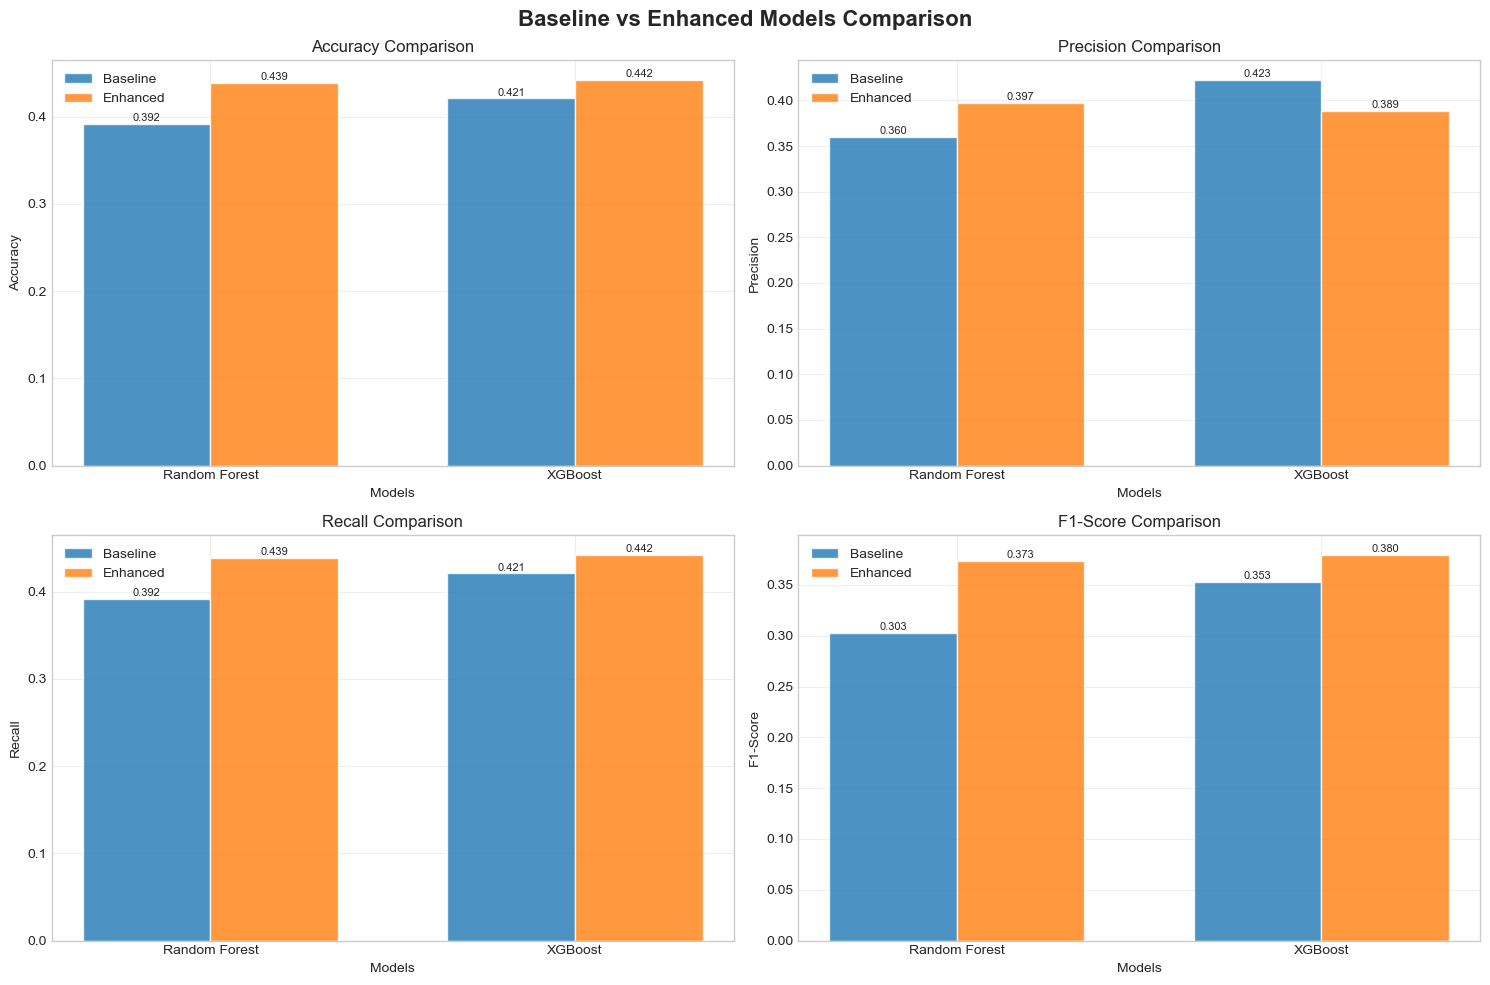

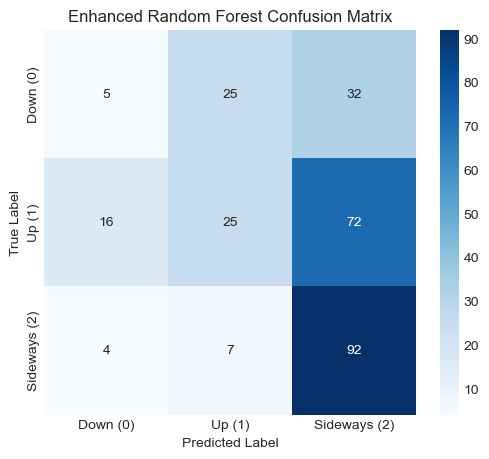

<Figure size 640x480 with 0 Axes>

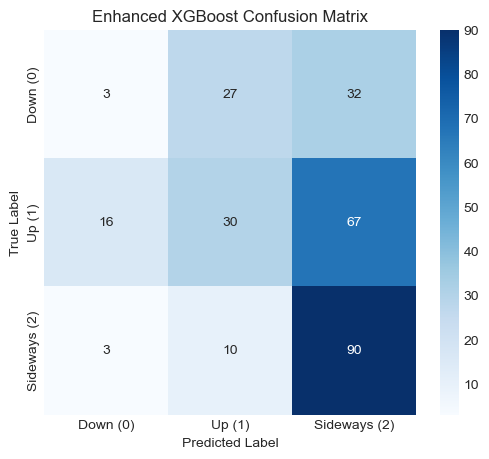

<Figure size 640x480 with 0 Axes>

In [27]:
# Visualize performance comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Baseline vs Enhanced Models Comparison', fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for plotting
    models = ['Random Forest', 'XGBoost']
    baseline_values = [comparison_df[comparison_df['model'].str.contains(model) & 
                                   comparison_df['model'].str.contains('Baseline')][metric].values[0] 
                      for model in models]
    enhanced_values = [comparison_df[comparison_df['model'].str.contains(model) & 
                                   comparison_df['model'].str.contains('Enhanced')][metric].values[0] 
                      for model in models]
    
    # Create bar plot
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8)
    bars2 = ax.bar(x + width/2, enhanced_values, width, label='Enhanced', alpha=0.8)
    
    ax.set_xlabel('Models')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(run_directory, 'performance_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Add confusion matrix plots for enhanced models
from sklearn.metrics import ConfusionMatrixDisplay
# Confusion Matrix for Enhanced Random Forest
rf_enh_cm = confusion_matrix(rf_data['y_test'], rf_enh_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_enh_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'], 
            yticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Enhanced Random Forest Confusion Matrix')
plt.show()
# save confusion matrix figure
plt.savefig(os.path.join(run_directory, 'rf_enhanced_confusion_matrix.png'))

# Confusion Matrix for Enhanced XGBoost
xgb_enh_cm = confusion_matrix(xgb_data['y_test'], xgb_enh_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(xgb_enh_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'], 
            yticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Enhanced XGBoost Confusion Matrix')
plt.show()
# save the confusion matrix
plt.savefig(os.path.join(run_directory, 'xgb_enhanced_confusion_matrix.png'))



In [28]:
# Feature importance analysis for enhanced models
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'feature': enhanced_features['rf'],
    'importance': rf_enhanced.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Random Forest Features:")
print(rf_importance.head(10))

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'feature': enhanced_features['xgb'],
    'importance': xgb_enhanced.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 XGBoost Features:")
print(xgb_importance.head(10))

# Save feature importance
rf_importance.to_csv(os.path.join(run_directory, 'rf_feature_importance.csv'), index=False)
xgb_importance.to_csv(os.path.join(run_directory, 'xgb_feature_importance.csv'), index=False)

# Check if engineered features are in top features
ama_rank_rf = rf_importance[rf_importance['feature'] == ama_feature_name].index[0] + 1 if ama_feature_name in rf_importance['feature'].values else 'Not found'
fdi_rank_rf = rf_importance[rf_importance['feature'] == fdi_feature_name].index[0] + 1 if fdi_feature_name in rf_importance['feature'].values else 'Not found'

ama_rank_xgb = xgb_importance[xgb_importance['feature'] == ama_feature_name].index[0] + 1 if ama_feature_name in xgb_importance['feature'].values else 'Not found'
fdi_rank_xgb = xgb_importance[xgb_importance['feature'] == fdi_feature_name].index[0] + 1 if fdi_feature_name in xgb_importance['feature'].values else 'Not found'

print(f"\nEngineered Features Ranking:")
print(f"AMA (Random Forest): {ama_rank_rf}")
print(f"FDI (Random Forest): {fdi_rank_rf}")
print(f"AMA (XGBoost): {ama_rank_xgb}")
print(f"FDI (XGBoost): {fdi_rank_xgb}")

FEATURE IMPORTANCE ANALYSIS
Top 10 Random Forest Features:
                  feature  importance
26  Volume_Osc_tick_12_26    0.106143
13      Normalized_Vol_20    0.071196
6             BB_Width_20    0.055215
5               BB_Std_20    0.053868
15      Normalized_Vol_50    0.050031
9            ATR_Ratio_20    0.043674
25   Volume_Osc_tick_5_10    0.034503
3               MACD_Line    0.033022
0             SMA_Dist_50    0.031759
16          GK_Volatility    0.028794

Top 10 XGBoost Features:
                  feature  importance
13  Volume_Osc_tick_12_26    0.144930
6            ATR_Ratio_20    0.076012
2               MACD_Line    0.072221
12   Volume_Osc_tick_5_10    0.071103
3             MACD_Signal    0.058497
7       Normalized_Vol_10    0.055741
20       FDI_GA_Optimized    0.054297
17    Returns_Kurtosis_20    0.051819
8           GK_Volatility    0.048514
10                 ROC_20    0.046598

Engineered Features Ranking:
AMA (Random Forest): 32
FDI (Random Forest): 33
A

## 9. Save Results and Metadata

Save all models, results, selected features, and metadata to the timestamped run directory.

In [29]:
# Save comprehensive results
print("="*60)
print("SAVING COMPREHENSIVE RESULTS")
print("="*60)

# Save comparison results
comparison_df.to_csv(os.path.join(run_directory, 'performance_comparison.csv'), index=False)
improvements_df.to_csv(os.path.join(run_directory, 'improvements_summary.csv'), index=False)

# Create comprehensive summary
summary = {
    'run_timestamp': timestamp,
    'run_directory': run_directory,
    'total_original_features': len(feature_names),
    'baseline_results': baseline_results,
    'enhanced_results': enhanced_results,
    'selected_features_count': {
        'rf': len(selected_features_rf),
        'xgb': len(selected_features_xgb)
    },
    'enhanced_features_count': {
        'rf': len(enhanced_features_rf),
        'xgb': len(enhanced_features_xgb)
    },
    'ga_parameters': ga_params,
    'feature_engineering_parameters': ga_fe_params,
    'engineered_features_info': engineered_features_info,
    'execution_times': {
        'rf_ga_selection': rf_ga_time,
        'xgb_ga_selection': xgb_ga_time,
        'ama_engineering': ama_time,
        'fdi_engineering': fdi_time
    }
}

# Save comprehensive summary
with open(os.path.join(run_directory, 'run_summary.pkl'), 'wb') as f:
    pickle.dump(summary, f)

# Save as JSON for human readability (excluding non-serializable objects)
json_summary = {
    'run_timestamp': timestamp,
    'run_directory': run_directory,
    'total_original_features': len(feature_names),
    'selected_features_count': summary['selected_features_count'],
    'enhanced_features_count': summary['enhanced_features_count'],
    'ga_parameters': ga_params,
    'feature_engineering_parameters': ga_fe_params,
    'execution_times': summary['execution_times'],
    'baseline_results': baseline_results,
    'enhanced_results': enhanced_results
}

with open(os.path.join(run_directory, 'run_summary.json'), 'w') as f:
    json.dump(json_summary, f, indent=2)

print(f"Comprehensive results saved to: {run_directory}")

SAVING COMPREHENSIVE RESULTS
Comprehensive results saved to: run_20251029_103554


In [30]:
# Create final summary report
print("="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print(f"Run completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Results saved in: {run_directory}")
print(f"Total execution time: {time.time() - time.time():.2f} seconds")

print(f"\nDataset Summary:")
print(f"  • Original features: {len(feature_names)}")
print(f"  • Training samples: {len(X_train_scaled)}")
print(f"  • Validation samples: {len(X_val_scaled)}")
print(f"  • Test samples: {len(X_test_scaled)}")

print(f"\nFeature Selection Results:")
for model, count in summary['selected_features_count'].items():
    reduction = (1 - count/len(feature_names)) * 100
    print(f"  • {model.upper()}: {count} features ({reduction:.1f}% reduction)")

print(f"\nFeature Engineering Results:")
print(f"  • AMA optimized parameters: {ama_details['best_parameters']}")
print(f"  • FDI optimized parameters: {fdi_details['best_parameters']}")

print(f"\nPerformance Improvements:")
for _, row in improvements_df.iterrows():
    model_name = row['model_pair'].split(' → ')[0].replace(' Baseline', '')
    print(f"  • {model_name}:")
    # Ensure the row contains the expected keys before accessing
    if 'accuracy_improvement' in row and 'f1_improvement' in row:
        print(f"    - Accuracy: {row['accuracy_improvement']:+.4f}")
        print(f"    - F1-Score: {row['f1_improvement']:+.4f}")
    else:
        print(f"    - Accuracy: Key not found")
        print(f"    - F1-Score: Key not found")
        
print(f"\nFiles Saved:")
saved_files = [f for f in os.listdir(run_directory) if not f.startswith('.')]
for file in sorted(saved_files):
    print(f"  • {file}")

print("\n" + "="*80)
print("WORKFLOW COMPLETED SUCCESSFULLY!")
print("="*80)

FINAL SUMMARY REPORT
Run completed at: 2025-10-29 12:16:32
Results saved in: run_20251029_103554
Total execution time: 0.00 seconds

Dataset Summary:
  • Original features: 116
  • Training samples: 2218
  • Validation samples: 277
  • Test samples: 278

Feature Selection Results:
  • RF: 3 features (97.4% reduction)
  • XGB: 3 features (97.4% reduction)

Feature Engineering Results:
  • AMA optimized parameters: [0.2438400315854124, 42, 8, 47]
  • FDI optimized parameters: [14, 1.8552187197860246, 2.0]

Performance Improvements:
  • Random Forest:
    - Accuracy: +0.0468
    - F1-Score: +0.0704
  • XGBoost:
    - Accuracy: +0.0216
    - F1-Score: +0.0265

Files Saved:
  • README.txt
  • X_test_scaled.pkl
  • X_train_scaled.pkl
  • X_val_scaled.pkl
  • baseline_results.csv
  • engineered_features_info.pkl
  • enhanced_features.pkl
  • feature_names.pkl
  • improvements_summary.csv
  • performance_comparison.csv
  • performance_comparison.png
  • rf_baseline.pkl
  • rf_baseline_confusio